# Part II – Incorporating Depth Information (RGB-D Extension)

## Imports

In [1]:
import cv2
import numpy as np
import glob
import os
import matplotlib.pyplot as plt

## 3D Point Extraction and Registration

### Camera Intrinsics

In [2]:
fx, fy = 1000.0, 1000.0  # focal lengths in pixels
cx, cy = 1920/2, 1080/2  # principal point at image center
K = np.array([[fx, 0, cx],
              [0, fy, cy],
              [0, 0, 1]], dtype=np.float32)

### Load Frames

In [3]:
image_files = glob.glob('../DATASETS/lisbon/*.jpg')
image_files.sort()  # DO NOT REMOVE!!!

### Convert 2D features to 3D directions using intrinsics

In [4]:
max_corners = 500
quality_level = 0.01
min_distance = 10

all_feature_points = []  # 2D points per frame
all_rays_per_frame = []  # normalized rays per frame

# Process first frame
first_img = cv2.imread(image_files[0])
prev_gray = cv2.cvtColor(first_img, cv2.COLOR_BGR2GRAY)
prev_corners = cv2.goodFeaturesToTrack(prev_gray,
                                       maxCorners=max_corners,
                                       qualityLevel=quality_level,
                                       minDistance=min_distance)

if prev_corners is None:
    raise ValueError("No features detected in the first frame!")

prev_corners = prev_corners.reshape(-1,2)
all_feature_points.append(prev_corners)

# Compute normalized rays for first frame
rays = np.array([[(u-cx)/fx, (v-cy)/fy, 1.0] for (u,v) in prev_corners])
rays /= np.linalg.norm(rays, axis=1)[:, np.newaxis]
all_rays_per_frame.append(rays)

# Track features across subsequent frames
for fname in image_files[1:]:
    img = cv2.imread(fname)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # Calculate optical flow
    next_pts, status, _ = cv2.calcOpticalFlowPyrLK(prev_gray, gray, prev_corners.astype(np.float32), None)

    # Keep only successfully tracked points
    good_prev = prev_corners[status.flatten() == 1]
    good_next = next_pts[status.flatten() == 1]

    if len(good_next) == 0:
        print(f"No features tracked in {fname}")
        continue

    # Save 2D points and rays
    all_feature_points.append(good_next)
    rays = np.array([[(u-cx)/fx, (v-cy)/fy, 1.0] for (u,v) in good_next])
    rays /= np.linalg.norm(rays, axis=1)[:, np.newaxis]
    all_rays_per_frame.append(rays)

    prev_gray = gray.copy()
    prev_corners = good_next

print(f"Processed {len(all_rays_per_frame)} frames with tracked features")

Processed 900 frames with tracked features


### Visualizing Feature Macthing

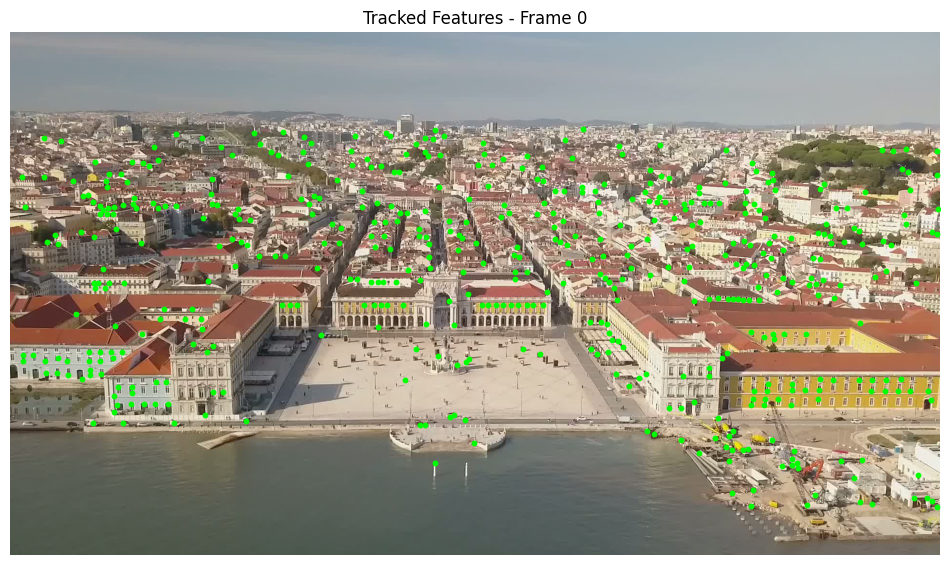

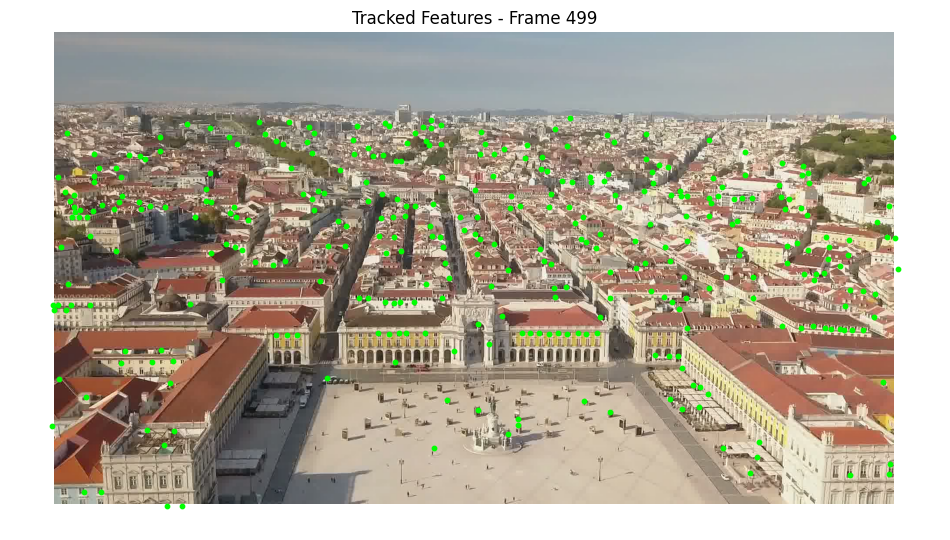

In [5]:
# Frame = 0
frame_idx = 0
img = cv2.imread(image_files[frame_idx])
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

features = all_feature_points[frame_idx]

plt.figure(figsize=(12,8))
plt.imshow(img)
plt.scatter(features[:,0], features[:,1], c='lime', s=10)  # draw points
plt.title(f"Tracked Features - Frame {frame_idx}")
plt.axis('off')
plt.show()

# Frame = 499
frame_idx = 499
img = cv2.imread(image_files[frame_idx])
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

features = all_feature_points[frame_idx]

plt.figure(figsize=(12,8))
plt.imshow(img)
plt.scatter(features[:,0], features[:,1], c='lime', s=10)
plt.title(f"Tracked Features - Frame {frame_idx}")
plt.axis('off')
plt.show()

### Visualizing PointClouds

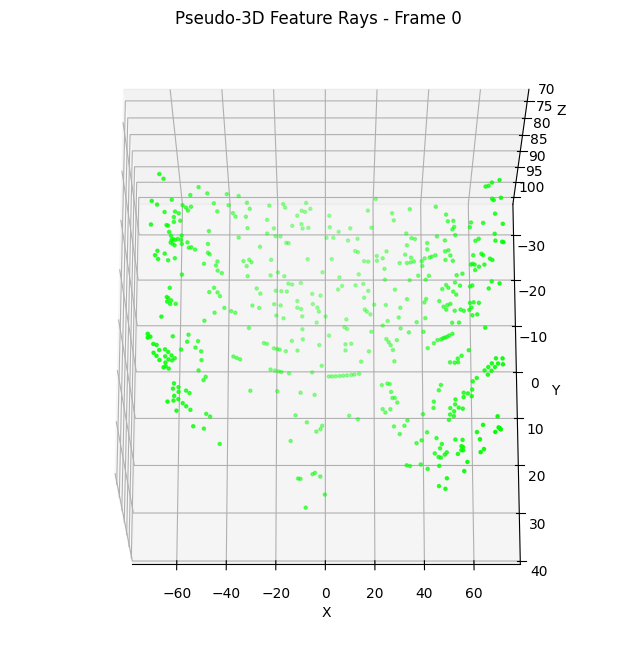

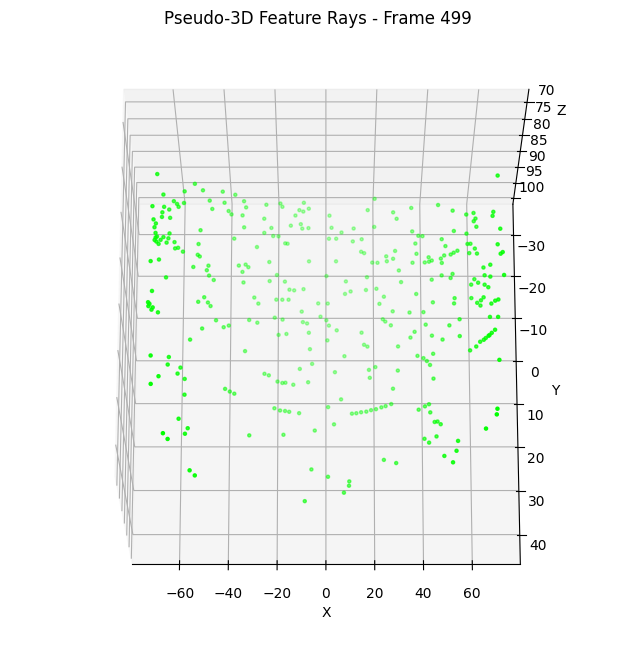

In [6]:
# Frame = 0
frame_idx = 0
rays = all_rays_per_frame[frame_idx]

scale = 100.0
points_3d = rays * scale

fig = plt.figure(figsize=(10,8))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(points_3d[:,0], points_3d[:,1], points_3d[:,2], c='lime', s=5)

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.set_title(f'Pseudo-3D Feature Rays - Frame {frame_idx}')
ax.view_init(elev=-110, azim=270)

plt.show()

# frame = 500
frame_idx = 499
rays = all_rays_per_frame[frame_idx]

scale = 100.0
points_3d = rays * scale

fig = plt.figure(figsize=(10,8))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(points_3d[:,0], points_3d[:,1], points_3d[:,2], c='lime', s=5)

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.set_title(f'Pseudo-3D Feature Rays - Frame {frame_idx}')
ax.view_init(elev=-110, azim=270)

plt.show()


### Rigid 3D Transformation

In [7]:
def procrustes_rigid(A, B):
    centroid_A = A.mean(axis=0)
    centroid_B = B.mean(axis=0)
    
    A_centered = A - centroid_A
    B_centered = B - centroid_B

    H = A_centered.T @ B_centered

    # SVD
    U, S, Vt = np.linalg.svd(H)
    R = Vt.T @ U.T

    # Handle reflection
    if np.linalg.det(R) < 0:
        Vt[2,:] *= -1
        R = Vt.T @ U.T

    t = centroid_B - R @ centroid_A

    return R, t

A = all_rays_per_frame[0]
B = all_rays_per_frame[1]

R, t = procrustes_rigid(A, B)

print("Estimated rotation R:\n", R)
print("Estimated translation t:\n", t)

Estimated rotation R:
 [[ 9.99999987e-01  4.58877371e-05  1.55003761e-04]
 [-4.59355519e-05  9.99999951e-01  3.08485901e-04]
 [-1.54989598e-04 -3.08493017e-04  9.99999940e-01]]
Estimated translation t:
 [ 2.99850418e-05 -1.70827769e-04 -1.15908404e-04]


## Robust Estimation with RANSAC

### Reject outlier 3D correspondences that violate the planar or rigid transformation model

In [8]:
def procrustes_ransac(A, B, num_iters=100, inlier_thresh=0.01):

    best_inliers = []
    best_R = None
    best_t = None
    N = A.shape[0]

    if N < 3:
        raise ValueError("Need at least 3 points for Procrustes")

    for _ in range(num_iters):
        # Randomly sample 3 points
        idx = np.random.choice(N, 3, replace=False)
        try:
            R, t = procrustes_rigid(A[idx], B[idx])
        except np.linalg.LinAlgError:
            continue

        A_transformed = (R @ A.T).T + t

        errors = np.linalg.norm(A_transformed - B, axis=1)

        # Determine inliers
        inliers = np.where(errors < inlier_thresh)[0]

        if len(inliers) > len(best_inliers):
            best_inliers = inliers
            best_R = R
            best_t = t

    # Recompute R, t using all inliers
    if len(best_inliers) >= 3:
        best_R, best_t = procrustes_rigid(A[best_inliers], B[best_inliers])
    else:
        raise ValueError("Not enough inliers found")

    return best_R, best_t, best_inliers

A = all_rays_per_frame[0]
B = all_rays_per_frame[1]

R_ransac, t_ransac, inliers = procrustes_ransac(A, B, num_iters=200, inlier_thresh=0.01)

print("RANSAC Estimated rotation R:\n", R_ransac)
print("RANSAC Estimated translation t:\n", t_ransac)
print(f"Number of inliers: {len(inliers)} / {A.shape[0]}")

RANSAC Estimated rotation R:
 [[ 9.99999987e-01  4.58877371e-05  1.55003761e-04]
 [-4.59355519e-05  9.99999951e-01  3.08485901e-04]
 [-1.54989598e-04 -3.08493017e-04  9.99999940e-01]]
RANSAC Estimated translation t:
 [ 2.99850418e-05 -1.70827769e-04 -1.15908404e-04]
Number of inliers: 500 / 500


### Improving robustness against mismatched features or moving elements

In [9]:
def filter_by_motion(prev_pts, next_pts, scale=1.0):
    """
    Removes points that move too much compared to median motion.
    prev_pts, next_pts: Nx2 arrays
    scale: multiplier of median motion to define max allowed motion
    Returns: indices of points kept
    """
    motion = np.linalg.norm(next_pts - prev_pts, axis=1)
    median_motion = np.median(motion)
    keep = np.where(motion < median_motion * scale)[0]
    return keep


In [10]:
for i in range(len(all_feature_points)-1):
    prev_pts = all_feature_points[i]
    next_pts = all_feature_points[i+1]

    N = min(len(prev_pts), len(next_pts))
    prev_pts = prev_pts[:N]
    next_pts = next_pts[:N]

    keep_idx = filter_by_motion(prev_pts, next_pts, scale=5.0)  # more tolerant
    if len(keep_idx) < 3:
        print(f"Frame {i}->{i+1}: too few points, skipping")
        continue

    A_filtered = all_rays_per_frame[i][keep_idx]
    B_filtered = all_rays_per_frame[i+1][keep_idx]

    try:
        R_ransac, t_ransac, inliers = procrustes_ransac(A_filtered, B_filtered, inlier_thresh=0.02)
    except ValueError:
        print(f"Frame {i}->{i+1}: RANSAC failed, skipping")
print("Finished successfully!")

Frame 58->59: RANSAC failed, skipping
Frame 99->100: RANSAC failed, skipping
Frame 134->135: RANSAC failed, skipping
Frame 155->156: RANSAC failed, skipping
Frame 192->193: RANSAC failed, skipping
Frame 253->254: RANSAC failed, skipping
Frame 254->255: RANSAC failed, skipping
Frame 258->259: RANSAC failed, skipping
Frame 335->336: RANSAC failed, skipping
Frame 339->340: RANSAC failed, skipping
Frame 342->343: RANSAC failed, skipping
Frame 366->367: RANSAC failed, skipping
Frame 375->376: RANSAC failed, skipping
Frame 392->393: RANSAC failed, skipping
Frame 397->398: RANSAC failed, skipping
Frame 399->400: RANSAC failed, skipping
Frame 424->425: RANSAC failed, skipping
Frame 426->427: RANSAC failed, skipping
Frame 427->428: RANSAC failed, skipping
Frame 441->442: RANSAC failed, skipping
Frame 456->457: RANSAC failed, skipping
Frame 460->461: RANSAC failed, skipping
Frame 467->468: RANSAC failed, skipping
Frame 483->484: RANSAC failed, skipping
Frame 508->509: RANSAC failed, skipping
Fra